# Data Visualization
This notebook describes how the finalized visualization was generated to address the question of interest: 

**Which US counties emit the most CO₂ from non-residential fuel use per square meter of building floor area?**

In [34]:
#%pip install geopandas 

In [35]:
#%pip install duckdb
#%pip install pandas 
import duckdb as duckdb 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd

In [36]:
# Establish connection 
# Established connection to database
conn = duckdb.connect("/Users/vedikashirtekar/MEDS/EDS-213/eds-213-labs/my-db.duckdb")

In [37]:
sources_emissions_top_10 = conn.sql("""SELECT s.source_name, s.iso3_country, SUM(e.emissions_quantity), s.capacity,
    ROUND(SUM(e.emissions_quantity) / (s.capacity), 6) AS co2_per_m2
    FROM sources s
    JOIN emission_records e ON s.source_id = e.source_id
    WHERE e.sector LIKE 'buildings' AND e.
    GROUP BY s.source_name, s.iso3_country, s.capacity
    ORDER BY co2_per_m2 DESC""").df()

ParserException: Parser Error: syntax error at or near "BY"

LINE 6:     GROUP BY s.source_name, s.iso3_country, s.capacity
                  ^

In [ ]:
# We are going to execute the SQL developed here using .sql 
sources_emissions = conn.sql("""SELECT s.source_name, start_time, AVG(e.emissions_quantity), ANY_VALUE(lat), ANY_VALUE(lon), s.capacity, ROUND(SUM(e.emissions_quantity) / (s.capacity), 4) AS co2_per_m2 
                             FROM sources s LEFT JOIN emission_records e ON s.source_id = e.source_id 
                             WHERE e.sector LIKE 'buildings' 
                             GROUP BY s.source_name, s.capacity, start_time
                             ORDER BY co2_per_m2 DESC""").df()

In [ ]:
# We can now drop the NANs... 
sources_emissions_clean = sources_emissions.dropna()
sources_emissions_clean_top_10 = sources_emissions_clean_top_10.dropna().head(10)
sources_emissions_clean = sources_emissions_clean.sort_values("start_time")
sources_emissions_clean.to_csv('data/new_tables/sources_emissions_clean.csv', index=False)

In [ ]:
# Dependencies pip freeze  > requirements.txt
# read in the sources_emissions_clean data as geopandas 


In [ ]:
#sources_top_10 = sources_emissions_clean
# Export
#sources_top_10.to_csv('data/new_tables/sources_top10.csv', index=False)
#sources_top_10


,source_name,start_time,avg(e.emissions_quantity),any_value(lat),any_value(lon),capacity,co2_per_m2
25805,Nacogdoches County,2021-01-01,2904.76000,31.617782,-94.617695,7.916967e+05,0.0037
16423,Berks County,2021-01-01,21185.64800,40.416515,-75.927047,5.003053e+06,0.0042
63636,Lafayette County,2021-01-01,1353.33600,39.065022,-93.789022,5.269194e+05,0.0026
63650,Marshall County,2021-01-01,762.28600,34.027128,-96.771299,2.986166e+05,0.0026
16407,Owyhee County,2021-01-01,90.28300,42.582056,-116.170417,2.124671e+04,0.0042
...,...,...,...,...,...,...,...
51153,Fulton County,2026-01-01,90998.15899,33.790060,-84.467097,3.179429e+07,0.0029
20861,Otter Tail County,2026-01-01,2768.82345,46.409550,-95.708229,7.060003e+05,0.0039
20849,Providence County,2026-01-01,43370.04858,41.871159,-71.578869,1.118414e+07,0.0039
20830,Morgan County,2026-01-01,147.64574,39.620276,-81.852882,3.753701e+04,0.0039


NameError: name 'sources_top_10' is not defined

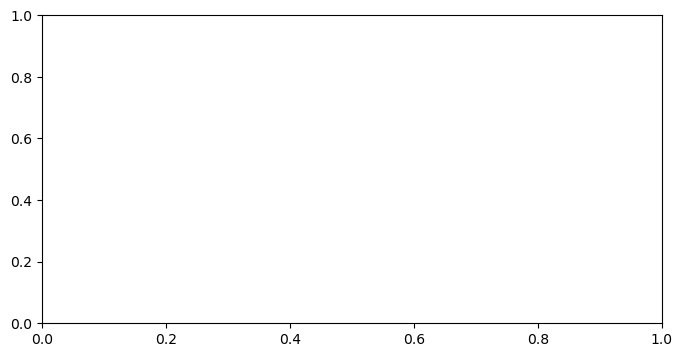

In [ ]:
# We can create a ranked bar chart 
fig, ax = plt.subplots(figsize = (8,4))
source_name = sources_emissions_clean_top_10["source_name"]
co2_per_m2 = sources_emissions_clean_top_10["co2_per_m2"]
ax.barh(source_name, co2_per_m2)
ax.invert_yaxis() # Read the sources top to bottom
ax.set(title = "CO${_2}$ Emissions per m${^2}$ Per Non-Residential Source")

#### Create a map with variable sizes in the power plant sizes for about ten years (animate through time)


In [ ]:
conn.close() #To ensure lock isn't there